# PF00042 data and score exploration

This notebook begins the data-exploration stage after the complete protein-to-graph pipeline. It answers the question recorded on 18 August: **does a protein pair that scores highly under one method also score highly under the others?**

It uses the same 66 unique pairs from the 12-sequence PF00042 globin pilot for Biopython local alignment, BLASTP, and eventually DEDAL. It preserves each method's native scale, uses Spearman rank correlation for the main test, and leaves missing BLAST hits as missing values. It does **not** build graphs or choose thresholds.

In [1]:
import json
import math
import subprocess
import sys
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from protein_alignment_networks import pair_rank_disagreements

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATASET_DIRECTORY = PROJECT_ROOT / "data/processed/pfam_pf00042_globin_pilot"
OUTPUT_DIRECTORY = PROJECT_ROOT / "outputs/tables/pfam_pf00042_correlation"
FIGURE_DIRECTORY = PROJECT_ROOT / "outputs/figures/pfam_pf00042_correlation"
FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)

## 1. Confirm the dataset

The analysis uses ungapped Pfam domain sequences, not the original multiple alignment. The metadata below makes the family composition visible before any scores are examined.

In [2]:
metadata = pd.read_csv(
    DATASET_DIRECTORY / "PF00042_globin_pilot_metadata.tsv", sep="\t"
)
dataset_manifest = json.loads(
    (DATASET_DIRECTORY / "PF00042_globin_pilot_manifest.json").read_text()
)

print(
    f"{dataset_manifest['selected_sequence_count']} sequences; "
    f"{dataset_manifest['pfam_version']}; "
    f"{len(metadata) * (len(metadata) - 1) // 2} unique pairs"
)
display(
    metadata[[
        "uniprot_accession",
        "uniprot_entry_name",
        "organism",
        "subgroup",
        "domain_length",
    ]]
)

12 sequences; PF00042.29; 66 unique pairs


,uniprot_accession,uniprot_entry_name,organism,subgroup,domain_length
0,P02204,MYG_CYPCA,Cyprinus carpio (Common carp),myoglobin,114
1,P02200,MYG_ALLMI,Alligator mississippiensis (American alligator),myoglobin,117
2,P02206,MYG_HETPO,Heterodontus portusjacksoni (Port Jackson shark),myoglobin,116
3,P02143,HBB_HETPO,Heterodontus portusjacksoni (Port Jackson shark),beta-like haemoglobin,112
4,P02133,HBB2_XENLA,Xenopus laevis (African clawed frog),beta-like haemoglobin,117
5,P04443,HBB0_MOUSE,Mus musculus (Mouse),beta-like haemoglobin,117
6,P02020,HBA_LEPPA,Lepidosiren paradoxus (South American lungfish),alpha-like haemoglobin,113
7,P06714,HBAT_HORSE,Equus caballus (Horse),alpha-like haemoglobin,111
8,P01967,HBA1_BOSGR,Bos grunniens (Wild yak) (Bos mutus grunniens),alpha-like haemoglobin,111
9,P09187,LGB1_MEDSA,Medicago sativa (Alfalfa),divergent globin,116


## 2. Generate or reuse method outputs

The runner records parameters, versions, runtimes, and checksums. Biopython and BLAST take only seconds on this pilot and are enabled below. DEDAL is deliberately opt-in because its model takes minutes to load and is much slower per pair. To complete the three-method run, change `METHODS_TO_RUN` to `('biopython', 'blast', 'dedal')`. Existing method outputs are reused unless `--force` is added manually.

In [3]:
RUN_METHODS = True
METHODS_TO_RUN = ("biopython", "blast")

if RUN_METHODS:
    command = [
        sys.executable,
        str(PROJECT_ROOT / "scripts/run_pf00042_correlation.py"),
        "--methods",
        *METHODS_TO_RUN,
        "--threads",
        "4",
    ]
    subprocess.run(command, cwd=PROJECT_ROOT, check=True)

Reusing biopython: /Users/davin/Desktop/Protein Seq Alignment/outputs/tables/pfam_pf00042_correlation/biopython_pairs.tsv
Reusing blast: /Users/davin/Desktop/Protein Seq Alignment/outputs/tables/pfam_pf00042_correlation/blast_pairs.tsv
Merged 66 canonical pairs
Completed methods: biopython, blast, dedal
Manifest: /Users/davin/Desktop/Protein Seq Alignment/outputs/tables/pfam_pf00042_correlation/run_manifest.json


## 3. Check coverage and provenance

An absent BLAST hit means BLAST reported no match at its E-value reporting threshold. It is not a numerical score of zero, so correlations use only pairs observed by both methods being compared.

In [4]:
scores = pd.read_csv(OUTPUT_DIRECTORY / "paired_scores.tsv", sep="\t")
correlations = pd.read_csv(
    OUTPUT_DIRECTORY / "spearman_correlations.tsv", sep="\t"
)
run_manifest = json.loads(
    (OUTPUT_DIRECTORY / "run_manifest.json").read_text()
)
score_columns = run_manifest["score_columns"]
coverage = pd.DataFrame(
    {
        "score": score_columns,
        "observed_pairs": [scores[column].notna().sum() for column in score_columns],
        "missing_pairs": [scores[column].isna().sum() for column in score_columns],
    }
)
print("Completed methods:", ", ".join(run_manifest["methods_completed"]))
display(coverage)
display(correlations)

Completed methods: biopython, blast, dedal


,score,observed_pairs,missing_pairs
0,biopython_score,66,0
1,blast_bit_score,50,16
2,dedal_sw_score,66,0
3,dedal_homology_logit,66,0


,score_a,score_b,spearman_rho,n_pairs
0,biopython_score,blast_bit_score,0.993036,50
1,biopython_score,dedal_sw_score,0.873681,66
2,biopython_score,dedal_homology_logit,0.873681,66
3,blast_bit_score,dedal_sw_score,0.891749,50
4,blast_bit_score,dedal_homology_logit,0.891749,50
5,dedal_sw_score,dedal_homology_logit,1.000000,66


### Examine BLAST's unreported pairs

The correlation involving BLAST describes only its reported pairs. The following check asks whether the omitted pairs tend to receive lower scores under the two complete methods and lists them for later biological inspection. This avoids overstating the apparently very high Biopython–BLAST agreement.

In [5]:
scores["blast_reported"] = scores["blast_bit_score"].notna()
complete_method_scores = [
    column
    for column in ["biopython_score", "dedal_sw_score"]
    if column in scores
]
blast_coverage_summary = (
    scores.groupby("blast_reported")[complete_method_scores]
    .agg(["count", "min", "median", "max"])
    .round(3)
)
display(blast_coverage_summary)
display(
    scores.loc[
        ~scores["blast_reported"],
        ["protein_a", "protein_b", *complete_method_scores],
    ].sort_values("biopython_score", ascending=False)
)

biopython_score                     dedal_sw_score         \
                         count   min median    max          count    min   
blast_reported                                                             
False                       16  22.0   43.0   81.0             16  4.762   
True                        50  27.0  105.5  355.0             50  6.628   

                                
                median     max  
blast_reported                  
False           11.559  16.491  
True            17.469  48.338

,protein_a,protein_b,biopython_score,dedal_sw_score
3,P01967,P02200,81.0,16.491179
41,P02200,P06714,66.0,12.159795
9,P01967,P24232,57.0,16.469696
8,P01967,P09187,53.0,11.046838
28,P02133,P24232,51.0,11.723434
61,P06714,P24232,49.0,12.057888
63,P09187,P24232,47.0,11.394275
54,P02206,P24232,45.0,13.205051
42,P02200,P09187,41.0,10.443895
48,P02204,P09187,36.0,10.274211


## 4. Inspect each score distribution

These plots show the native outputs separately. Their numerical ranges should not be compared directly: a BLAST bit score of 50 and a Biopython score of 50 do not have the same meaning.

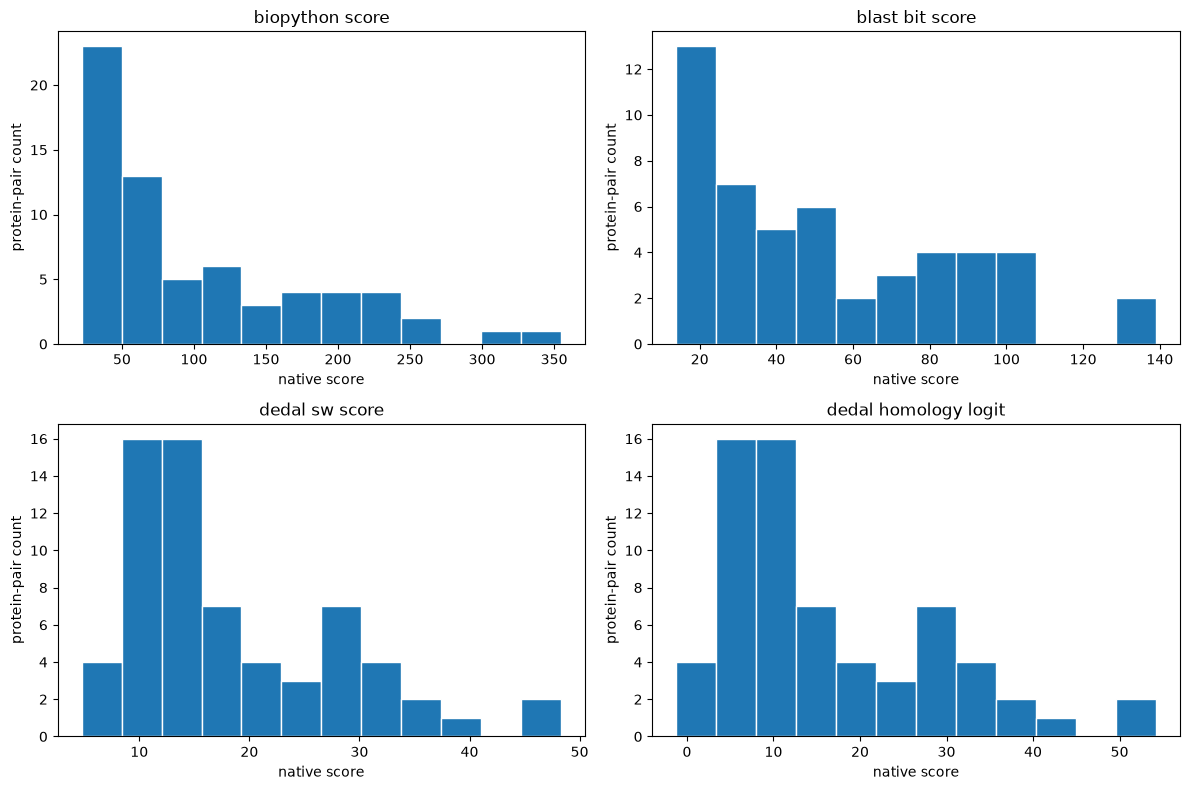

In [6]:
distribution_columns = min(2, len(score_columns))
distribution_rows = math.ceil(len(score_columns) / distribution_columns)
figure, axes = plt.subplots(
    distribution_rows,
    distribution_columns,
    figsize=(6 * distribution_columns, 4 * distribution_rows),
    squeeze=False,
)
for axis, column in zip(axes.flat, score_columns, strict=True):
    axis.hist(scores[column].dropna(), bins=12, edgecolor="white")
    axis.set_title(column.replace("_", " "))
    axis.set_xlabel("native score")
    axis.set_ylabel("protein-pair count")
for axis in axes.flat[len(score_columns) :]:
    axis.set_visible(False)
figure.tight_layout()
figure.savefig(FIGURE_DIRECTORY / "score_distributions.png", dpi=180)
plt.show()

## 5. Test whether high-scoring pairs agree

Spearman's correlation compares ranks rather than raw units. A value near `1` means that the two outputs order protein pairs similarly; near `0` means little monotonic agreement; near `-1` means reversed ordering. This is an exploratory result for this deliberately small family, not a general validation of either method.

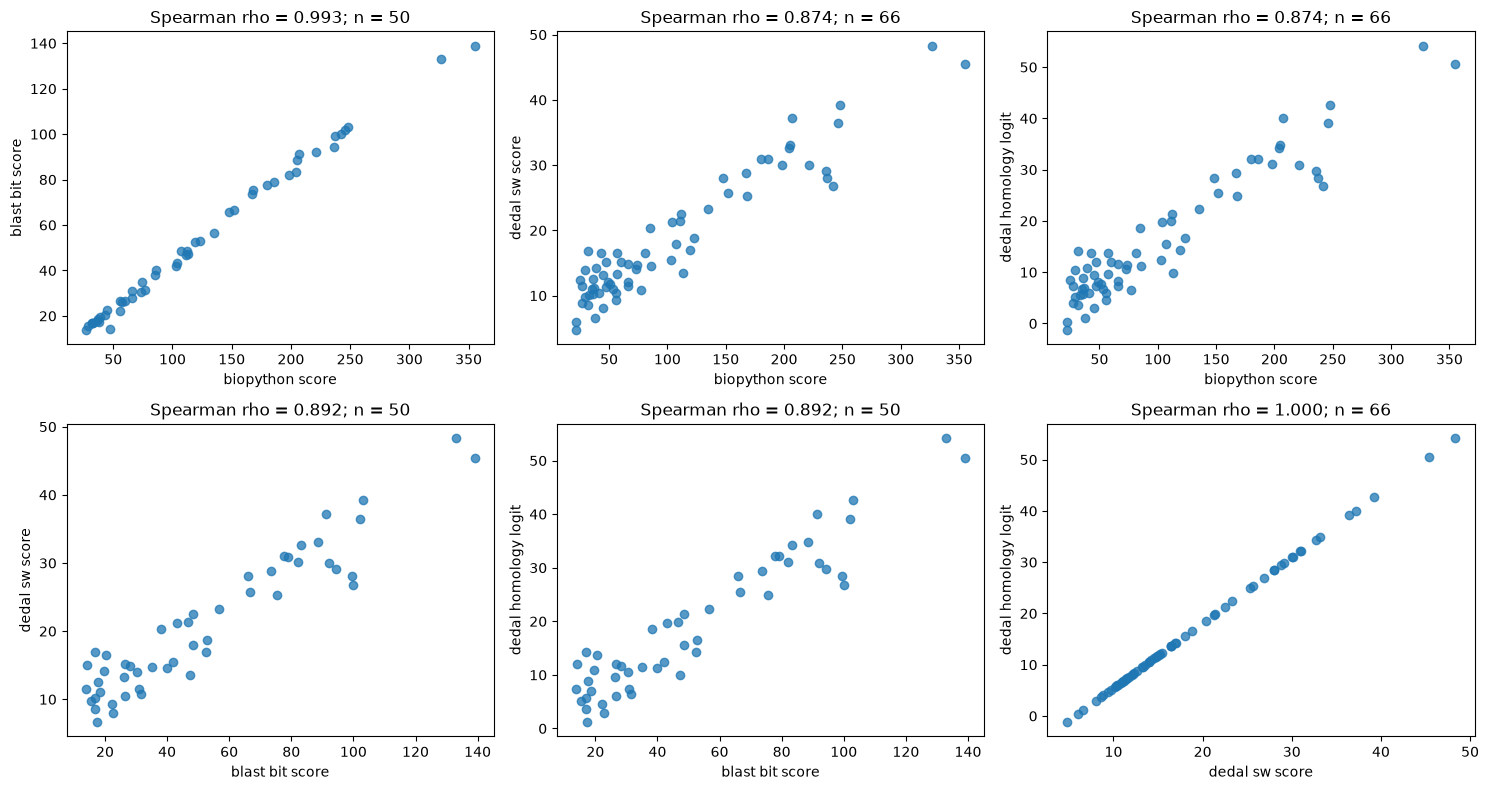

In [7]:
score_pairs = list(combinations(score_columns, 2))
scatter_columns = min(3, len(score_pairs))
scatter_rows = math.ceil(len(score_pairs) / scatter_columns)
figure, axes = plt.subplots(
    scatter_rows,
    scatter_columns,
    figsize=(5 * scatter_columns, 4 * scatter_rows),
    squeeze=False,
)
for axis, (score_a, score_b) in zip(axes.flat, score_pairs, strict=True):
    complete = scores[[score_a, score_b]].dropna()
    axis.scatter(complete[score_a], complete[score_b], alpha=0.75)
    result = correlations.query(
        "score_a == @score_a and score_b == @score_b"
    ).iloc[0]
    axis.set_title(
        f"Spearman rho = {result.spearman_rho:.3f}; n = {result.n_pairs:.0f}"
    )
    axis.set_xlabel(score_a.replace("_", " "))
    axis.set_ylabel(score_b.replace("_", " "))
for axis in axes.flat[len(score_pairs) :]:
    axis.set_visible(False)
figure.tight_layout()
figure.savefig(FIGURE_DIRECTORY / "pairwise_score_correlations.png", dpi=180)
plt.show()

## 6. Find informative disagreements

A high overall correlation can hide biologically interesting exceptions. For every two outputs, the table below ranks only their shared, non-missing pairs and reports the largest differences in percentile rank. These pairs are candidates for inspecting alignments, lengths, coverage, composition, and subgroup membership.

In [8]:
disagreement_tables = []
for score_a, score_b in score_pairs:
    disagreements = pair_rank_disagreements(scores, score_a, score_b).head(5)
    disagreements.insert(0, "comparison", f"{score_a} vs {score_b}")
    disagreement_tables.append(disagreements)

largest_disagreements = pd.concat(disagreement_tables, ignore_index=True)
display(largest_disagreements)

,comparison,protein_a,protein_b,biopython_score,blast_bit_score,biopython_score_complete_percentile,blast_bit_score_complete_percentile,absolute_percentile_difference,dedal_sw_score,dedal_sw_score_complete_percentile,dedal_homology_logit,dedal_homology_logit_complete_percentile
0,biopython_score vs blast_bit_score,P02020,P24232,47.0,14.2,0.240000,0.04,0.200000,NaN,NaN,NaN,NaN
1,biopython_score vs blast_bit_score,P02020,P02204,107.0,48.5,0.520000,0.57,0.050000,NaN,NaN,NaN,NaN
2,biopython_score vs blast_bit_score,P02143,P09187,45.0,22.7,0.220000,0.26,0.040000,NaN,NaN,NaN,NaN
3,biopython_score vs blast_bit_score,P02143,P24232,36.0,17.7,0.120000,0.16,0.040000,NaN,NaN,NaN,NaN
4,biopython_score vs blast_bit_score,P02200,P30627,56.0,26.6,0.270000,0.31,0.040000,NaN,NaN,NaN,NaN
5,biopython_score vs dedal_sw_score,P04443,P30627,32.0,NaN,0.128788,NaN,0.477273,16.898382,0.606061,NaN,NaN
6,biopython_score vs dedal_sw_score,P04443,P09187,77.0,NaN,0.545455,NaN,0.348485,10.841857,0.196970,NaN,NaN
7,biopython_score vs dedal_sw_score,P02200,P24232,29.0,NaN,0.098485,NaN,0.325758,13.935308,0.424242,NaN,NaN
8,biopython_score vs dedal_sw_score,P04443,P24232,43.0,NaN,0.272727,NaN,0.318182,16.496244,0.590909,NaN,NaN
9,biopython_score vs dedal_sw_score,P02133,P30627,25.0,NaN,0.045455,NaN,0.303030,12.336458,0.348485,NaN,NaN


## Interpretation checklist

Before moving to graphs, record:

1. Which method outputs are complete, and which protein pairs are missing?
2. Are correlations consistently high, or do they depend on the output chosen (for example DEDAL alignment score versus homology logit)?
3. Which pairs disagree most, and are those disagreements associated with the divergent globin subgroup, short alignment coverage, or another identifiable feature?
4. Does the pilot provide enough variation to justify testing a graph threshold, or should the dataset be expanded first?

Only after answering these questions should the project implement the selectable method-and-threshold data-to-graph stage.